### Probar modelo con el clasificador

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlp.mlp_main import MLP

In [73]:
# Getting data
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y= data.target

In [74]:
X.shape, y.shape

((150, 4), (150,))

In [75]:
X[:10], y[:10]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [76]:
# Data Wrangling
from sklearn.preprocessing import Normalizer

nrmlzr = Normalizer()
X_nml = nrmlzr.fit_transform(X)

In [77]:
X[:10], y[:10]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [78]:
# Estandarizar media 0 varianza 1
from sklearn.preprocessing import StandardScaler

std_scl = StandardScaler(
    with_mean=True,
    with_std=True
)

X_std = std_scl.fit_transform(X_nml)

In [79]:
# Encoder de Datos
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
y_encoded = ohe.fit_transform(y.reshape(-1, 1))
y_encoded[:10]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [80]:
from sklearn.model_selection import train_test_split

X_test, X_train, y_test, y_train = train_test_split(X_std, y_encoded, test_size=0.2, random_state=42)

In [81]:
# Training model

mlp = MLP(
    layers=[(4, 5, "sigmoid"),(5, 4, "sigmoid"), (4, 3, "softmax")],
    learning_rate=0.05,
)

history = mlp.train(X_train, y_train, epochs=1500, batch_size=32)

Epoch 0, MSE: 0.34533616004925166
Epoch 10, MSE: 0.31952345658849823
Epoch 20, MSE: 0.306876506203741
Epoch 30, MSE: 0.2900540362387469
Epoch 40, MSE: 0.2676670289964831
Epoch 50, MSE: 0.24122828085061787
Epoch 60, MSE: 0.21515177520641665
Epoch 70, MSE: 0.19332118458154468
Epoch 80, MSE: 0.17662058728717728
Epoch 90, MSE: 0.16407734242825314
Epoch 100, MSE: 0.15436828479853026
Epoch 110, MSE: 0.14642567760848707
Epoch 120, MSE: 0.13952699715255892
Epoch 130, MSE: 0.13322397751617762
Epoch 140, MSE: 0.12725699701740764
Epoch 150, MSE: 0.1214903890238949
Epoch 160, MSE: 0.11586770437693569
Epoch 170, MSE: 0.11038009493929864
Epoch 180, MSE: 0.10504333577150732
Epoch 190, MSE: 0.09988167501459287
Epoch 200, MSE: 0.0949177874875127
Epoch 210, MSE: 0.09016791426826029
Epoch 220, MSE: 0.08564074330007863
Epoch 230, MSE: 0.08133841044591908
Epoch 240, MSE: 0.07725828921014465
Epoch 250, MSE: 0.07339474537099504
Epoch 260, MSE: 0.06974049615691127
Epoch 270, MSE: 0.06628751253022076
Epoch 280

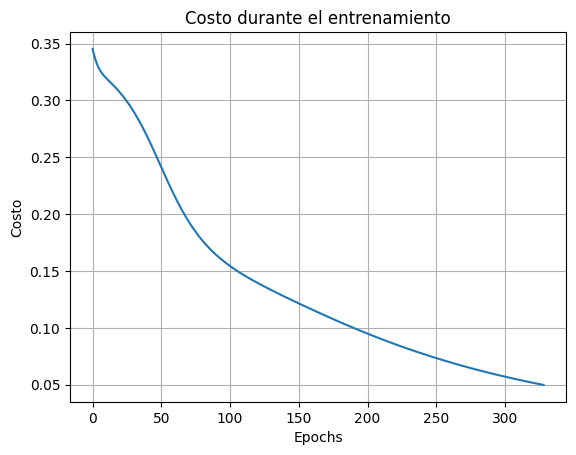

In [82]:
# Graficar funcion de costo

plt.plot(history)
plt.title("Costo durante el entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Costo")
plt.grid()
plt.show()

In [83]:
from sklearn.metrics import classification_report

y_pred = mlp.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        40
           1       0.97      0.85      0.91        41
           2       0.88      0.97      0.93        39

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



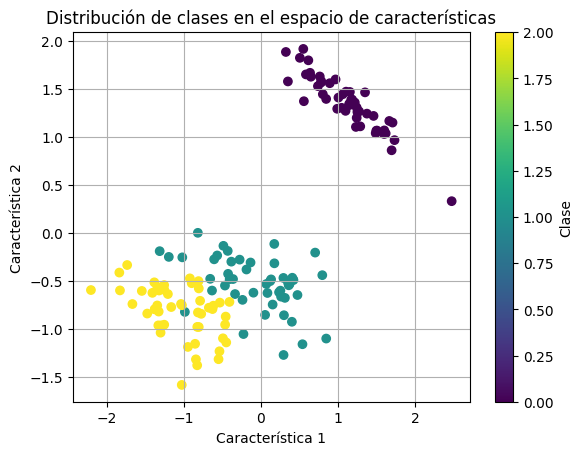

In [84]:
# Graficar distribucion de clases
plt.scatter(X_std[:, 0], X_std[:, 1], c=y, cmap="viridis")
plt.title("Distribución de clases en el espacio de características")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.colorbar(label="Clase")
plt.grid()
plt.show()

In [85]:
# Analisis con las dos primeras caracteristicas 

X_std_2d = X_std[:, :2]

In [86]:
X_std_2d[:10]

array([[1.18437674, 1.39102374],
       [1.73526784, 0.96746359],
       [1.21966217, 1.35970569],
       [1.09974145, 1.27268216],
       [0.89473547, 1.56092823],
       [0.7411829 , 1.53104162],
       [0.64924076, 1.62844696],
       [1.14846823, 1.33285942],
       [1.24432509, 1.20006661],
       [1.50682348, 1.06729926]])

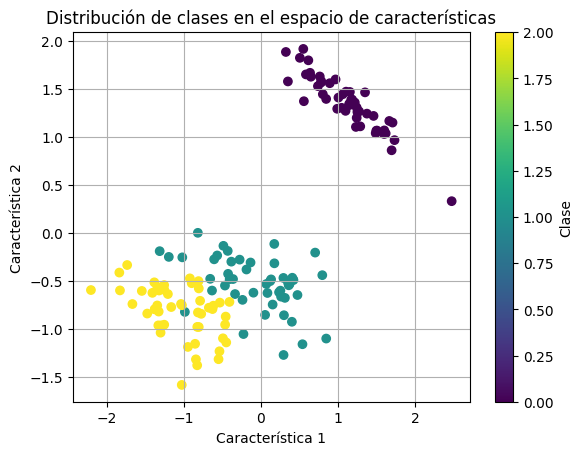

In [87]:
# Graficar distribucion de clases con las dos primeras caracteristicas

plt.scatter(X_std_2d[:, 0], X_std_2d[:, 1], c=y, cmap="viridis")
plt.title("Distribución de clases en el espacio de características")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.colorbar(label="Clase")
plt.grid()
plt.show()

In [88]:
# split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X_std_2d, y_encoded, test_size=0.2, random_state=42)


mlp_2d = MLP(
    layers=[(2, 5, "sigmoid"),(5, 4, "sigmoid"), (4, 3, "softmax")],
    learning_rate=0.05,
)

history_2d = mlp_2d.train(X_train, y_train, epochs=1500, batch_size=32)

Epoch 0, MSE: 0.33864894354034025
Epoch 10, MSE: 0.3140202837340116
Epoch 20, MSE: 0.23751553437479736
Epoch 30, MSE: 0.18215508601187658
Epoch 40, MSE: 0.16249180792501564
Epoch 50, MSE: 0.1463681212352251
Epoch 60, MSE: 0.12643595011644884
Epoch 70, MSE: 0.10485358126178929
Epoch 80, MSE: 0.08752163936216578
Epoch 90, MSE: 0.07520703106586905
Epoch 100, MSE: 0.06618971810351913
Epoch 110, MSE: 0.059284547935529015
Epoch 120, MSE: 0.05382607528899743
Last epoch: 129 with MSE: 0.049812324326445126


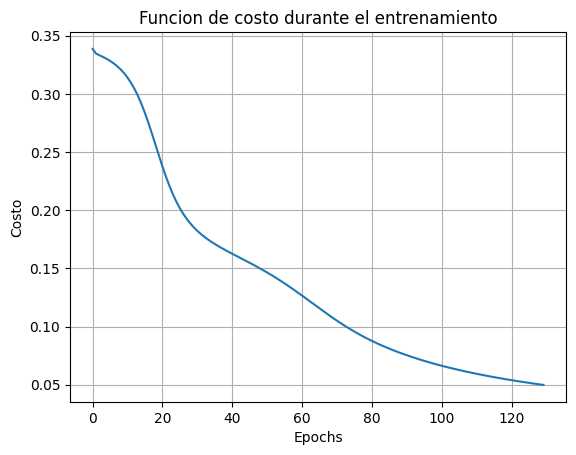

In [89]:
# Graficar funcion de costo

plt.plot(history_2d)
plt.title("Funcion de costo durante el entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Costo")
plt.grid()
plt.show()

In [90]:
# Test

y_pred = mlp_2d.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print(classification_report(y_test_classes, y_pred_classes))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

